In [1]:
import pandas as pd

# Load dataset
df = pd.read_parquet("hvac_data_cleaned.parquet")

# Preview data
print(df.head())

# Show columns
print(df.columns)

            timestamp  on_off  damper  active_energy  co2_1  ambient_humidity  \
0 2022-06-01 00:00:00     0.0     0.0      762617.80  975.0              35.0   
1 2022-06-01 00:05:00     0.0     0.0            NaN  977.0              35.0   
2 2022-06-01 00:10:00     0.0     0.0            NaN  975.0              35.0   
3 2022-06-01 00:15:00     0.0     0.0      762617.99  975.0              35.0   
4 2022-06-01 00:20:00     0.0     0.0            NaN  975.0              35.0   

   active_power  power_generated  high_pressure_1  high_pressure_2  \
0          0.51              4.0            15.09             15.0   
1          0.51              NaN            15.03             14.9   
2          0.51              NaN            15.03             14.8   
3          0.51              4.0            14.96             14.8   
4          0.51              NaN            14.90             14.7   

   low_pressure_1  low_pressure_2  high_pressure_3  low_pressure_3  \
0           15.27     

In [2]:
!pip install pyarrow


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

# Load dataset
df = pd.read_parquet("hvac_data_cleaned.parquet")

# Preview data
print(df.head())

# Show columns
print(df.columns)

            timestamp  on_off  damper  active_energy  co2_1  ambient_humidity  \
0 2022-06-01 00:00:00     0.0     0.0      762617.80  975.0              35.0   
1 2022-06-01 00:05:00     0.0     0.0            NaN  977.0              35.0   
2 2022-06-01 00:10:00     0.0     0.0            NaN  975.0              35.0   
3 2022-06-01 00:15:00     0.0     0.0      762617.99  975.0              35.0   
4 2022-06-01 00:20:00     0.0     0.0            NaN  975.0              35.0   

   active_power  power_generated  high_pressure_1  high_pressure_2  \
0          0.51              4.0            15.09             15.0   
1          0.51              NaN            15.03             14.9   
2          0.51              NaN            15.03             14.8   
3          0.51              4.0            14.96             14.8   
4          0.51              NaN            14.90             14.7   

   low_pressure_1  low_pressure_2  high_pressure_3  low_pressure_3  \
0           15.27     

In [4]:
python.exe -m pip install --upgrade pip

SyntaxError: invalid syntax (842801469.py, line 1)

In [ ]:
!pip install pyarrow

In [ ]:
import pandas as pd

df = pd.read_parquet("hvac_data_cleaned.parquet")

print(df.head())
print(df.columns)

In [ ]:
import sys
!{sys.executable} -m pip install pyarrow

In [ ]:
import pandas as pd

df = pd.read_parquet("hvac_data_cleaned.parquet")

print(df.head())
print(df.columns)

In [ ]:
import pandas as pd

df = pd.read_parquet(
    "hvac_data_cleaned.parquet",
    engine="pyarrow",
    dtype_backend="numpy_nullable"
)

print(df.head())
print(df.columns)

In [ ]:
import pyarrow.parquet as pq

table = pq.read_table("hvac_data_cleaned.parquet")
df = table.to_pandas(ignore_metadata=True)

print(df.head())
print(df.columns)

In [ ]:
import os

print(os.getcwd())
print(os.listdir())


In [ ]:
df = pd.read_parquet(r"C:\Users\jeffe\Downloads\hvac_data_cleaned.parquet")


In [ ]:
import pyarrow.parquet as pq

table = pq.read_table("hvac_data_cleaned.parquet")
df = table.to_pandas(ignore_metadata=True)

print(df.head())
print(df.columns)

In [ ]:
features = [
    "ambient_temp",
    "ambient_humidity",
    "active_power",
    "co2_1"
]

df_clean = df[features].dropna()

print(df_clean.head())

In [5]:
import pandas as pd

df = pd.read_parquet("hvac_data_cleaned.parquet")

print(df.head())

            timestamp  on_off  damper  active_energy  co2_1  ambient_humidity  \
0 2022-06-01 00:00:00     0.0     0.0      762617.80  975.0              35.0   
1 2022-06-01 00:05:00     0.0     0.0            NaN  977.0              35.0   
2 2022-06-01 00:10:00     0.0     0.0            NaN  975.0              35.0   
3 2022-06-01 00:15:00     0.0     0.0      762617.99  975.0              35.0   
4 2022-06-01 00:20:00     0.0     0.0            NaN  975.0              35.0   

   active_power  power_generated  high_pressure_1  high_pressure_2  \
0          0.51              4.0            15.09             15.0   
1          0.51              NaN            15.03             14.9   
2          0.51              NaN            15.03             14.8   
3          0.51              4.0            14.96             14.8   
4          0.51              NaN            14.90             14.7   

   low_pressure_1  low_pressure_2  high_pressure_3  low_pressure_3  \
0           15.27     

In [6]:
features = [
    "ambient_temp",
    "ambient_humidity",
    "active_power",
    "co2_1"
]

df_clean = df[features].dropna()

print(df_clean.head())

   ambient_temp  ambient_humidity  active_power  co2_1
0          23.4              35.0          0.51  975.0
1          23.3              35.0          0.51  977.0
2          23.4              35.0          0.51  975.0
3          23.3              35.0          0.51  975.0
4          23.3              35.0          0.51  975.0


In [7]:
from sklearn.ensemble import IsolationForest

# Train anomaly model
anomaly_model = IsolationForest(contamination=0.05, random_state=42)
anomaly_model.fit(df_clean)

# Predict anomalies
df_clean["anomaly"] = anomaly_model.predict(df_clean)

# Convert labels (-1 = anomaly → 1)
df_clean["anomaly"] = df_clean["anomaly"].map({1: 0, -1: 1})

print(df_clean.head())

   ambient_temp  ambient_humidity  active_power  co2_1  anomaly
0          23.4              35.0          0.51  975.0        0
1          23.3              35.0          0.51  977.0        0
2          23.4              35.0          0.51  975.0        0
3          23.3              35.0          0.51  975.0        0
4          23.3              35.0          0.51  975.0        0


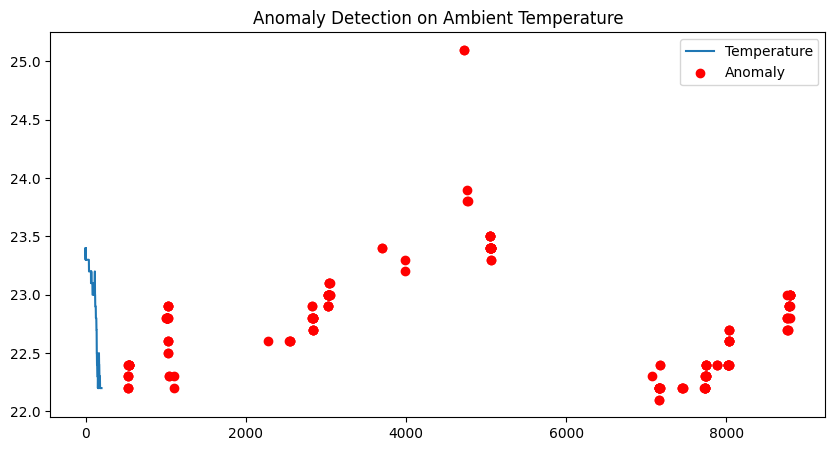

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_clean["ambient_temp"].values[:200], label="Temperature")

# highlight anomalies
anomalies = df_clean[df_clean["anomaly"] == 1]

plt.scatter(anomalies.index[:200],
            anomalies["ambient_temp"].iloc[:200],
            color="red", label="Anomaly")

plt.legend()
plt.title("Anomaly Detection on Ambient Temperature")
plt.show()

In [9]:
import numpy as np

df_sim = df_clean.copy()

# Pick random rows to turn into anomalies
np.random.seed(42)
anomaly_indices = np.random.choice(df_sim.index, size=30, replace=False)

# Simulate abnormal HVAC behavior
df_sim.loc[anomaly_indices, "ambient_temp"] += np.random.uniform(5, 10, size=30)
df_sim.loc[anomaly_indices, "ambient_humidity"] += np.random.uniform(15, 25, size=30)
df_sim.loc[anomaly_indices, "active_power"] += np.random.uniform(0.8, 1.5, size=30)
df_sim.loc[anomaly_indices, "co2_1"] += np.random.uniform(300, 600, size=30)

# Label the simulated anomalies for reference
df_sim["simulated_anomaly"] = 0
df_sim.loc[anomaly_indices, "simulated_anomaly"] = 1

print(df_sim.head())
print("Simulated anomalies added:", df_sim["simulated_anomaly"].sum())

   ambient_temp  ambient_humidity  active_power  co2_1  anomaly  \
0          23.4              35.0          0.51  975.0        0   
1          23.3              35.0          0.51  977.0        0   
2          23.4              35.0          0.51  975.0        0   
3          23.3              35.0          0.51  975.0        0   
4          23.3              35.0          0.51  975.0        0   

   simulated_anomaly  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  
Simulated anomalies added: 30


In [10]:
from sklearn.ensemble import IsolationForest

model_features = ["ambient_temp", "ambient_humidity", "active_power", "co2_1"]

anomaly_model = IsolationForest(contamination=0.05, random_state=42)
anomaly_model.fit(df_sim[model_features])

df_sim["predicted_anomaly"] = anomaly_model.predict(df_sim[model_features])
df_sim["predicted_anomaly"] = df_sim["predicted_anomaly"].map({1: 0, -1: 1})

print(df_sim[["simulated_anomaly", "predicted_anomaly"]].head())

   simulated_anomaly  predicted_anomaly
0                  0                  0
1                  0                  0
2                  0                  0
3                  0                  0
4                  0                  0


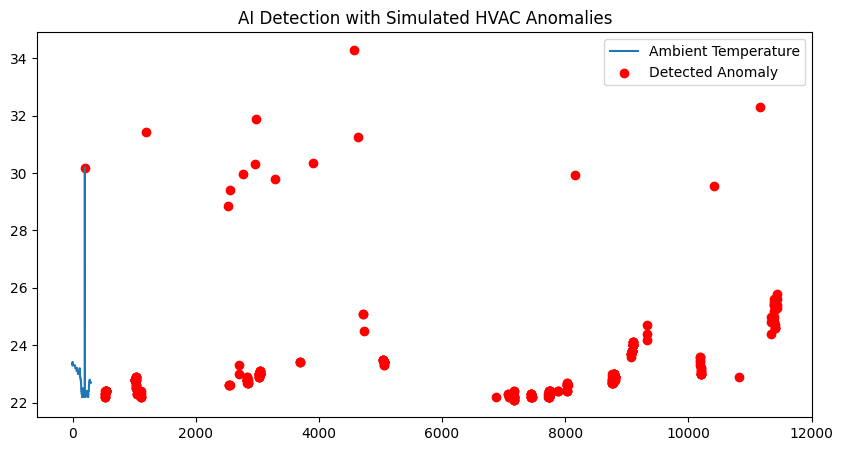

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_sim["ambient_temp"].values[:300], label="Ambient Temperature")

detected = df_sim[df_sim["predicted_anomaly"] == 1]

plt.scatter(
    detected.index[:300],
    detected["ambient_temp"].iloc[:300],
    color="red",
    label="Detected Anomaly"
)

plt.legend()
plt.title("AI Detection with Simulated HVAC Anomalies")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Features (inputs)
features = ["ambient_humidity", "active_power", "co2_1"]

# Target (what we predict)
target = "ambient_temp"

df_forecast = df_sim[features + [target]].dropna()

X = df_forecast[features]
y = df_forecast[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
forecast_model = LinearRegression()
forecast_model.fit(X_train, y_train)

# Predict
y_pred = forecast_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.9556260886922342


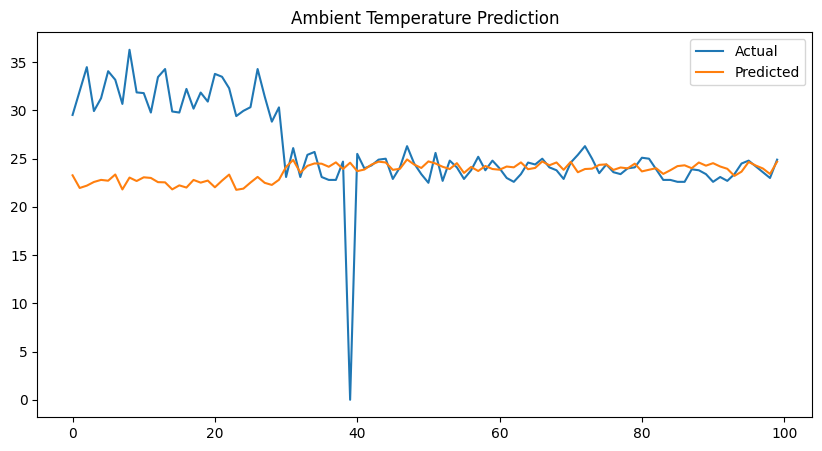

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.legend()
plt.title("Ambient Temperature Prediction")
plt.show()

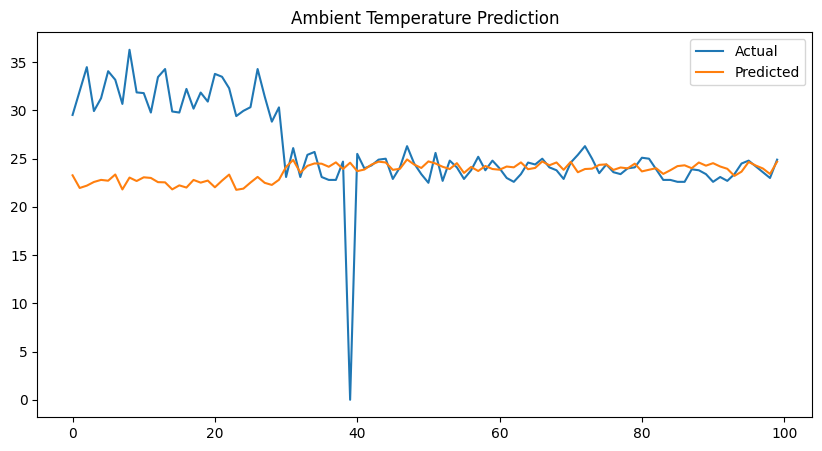

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.legend()
plt.title("Ambient Temperature Prediction")
plt.show()

In [15]:
def simulate_scenario(humidity, power, co2):
    input_data = [[humidity, power, co2]]

    # Predict temperature
    predicted_temp = forecast_model.predict(input_data)[0]

    # Check anomaly
    anomaly_check = anomaly_model.predict(
        [[predicted_temp, humidity, power, co2]]
    )
    status = "Anomaly" if anomaly_check[0] == -1 else "Normal"

    print("\n--- Scenario Result ---")
    print(f"Predicted Temperature: {predicted_temp:.2f}")
    print(f"System Status: {status}")

    # Insight logic
    if power > 1.0 and humidity > 50:
        print("Insight: Possible HVAC inefficiency")
    elif co2 > 1000:
        print("Insight: Poor ventilation")
    else:
        print("Insight: System appears normal")

In [16]:
simulate_scenario(45, 0.8, 900)
simulate_scenario(60, 1.5, 1200)


--- Scenario Result ---
Predicted Temperature: 24.67
System Status: Normal
Insight: System appears normal

--- Scenario Result ---
Predicted Temperature: 23.58
System Status: Anomaly
Insight: Possible HVAC inefficiency


C:\Users\jeffe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\jeffe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\jeffe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\jeffe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [17]:
import pandas as pd

def simulate_scenario(humidity, power, co2):
    
    # Create DataFrame with correct column names
    input_df = pd.DataFrame([{
        "ambient_humidity": humidity,
        "active_power": power,
        "co2_1": co2
    }])

    # Predict temperature
    predicted_temp = forecast_model.predict(input_df)[0]

    # Create full input for anomaly model
    anomaly_input = pd.DataFrame([{
        "ambient_temp": predicted_temp,
        "ambient_humidity": humidity,
        "active_power": power,
        "co2_1": co2
    }])

    anomaly_check = anomaly_model.predict(anomaly_input)
    status = "Anomaly" if anomaly_check[0] == -1 else "Normal"

    print("\n--- Scenario Result ---")
    print(f"Predicted Temperature: {predicted_temp:.2f}")
    print(f"System Status: {status}")

    # Insight logic
    if power > 1.0 and humidity > 50:
        print("Insight: Possible HVAC inefficiency")
    elif co2 > 1000:
        print("Insight: Poor ventilation")
    else:
        print("Insight: System appears normal")

In [18]:
simulate_scenario(45, 0.8, 900)
simulate_scenario(60, 1.5, 1200)


--- Scenario Result ---
Predicted Temperature: 24.67
System Status: Normal
Insight: System appears normal

--- Scenario Result ---
Predicted Temperature: 23.58
System Status: Anomaly
Insight: Possible HVAC inefficiency
